 Fairness & Subgroup Analysis 
 
**Objective:** Auditing the champion model (likely XGBoost) for bias across 'Sex' and 'Race' subgroups.


In [3]:

# %%
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score

sns.set_style('whitegrid')

#




1. Load Data & Champion Model

In [4]:

# %%
# Load Processed Validation Data (for predictions)
X_val_processed = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')

# Load XGBoost (or your best model)
model = joblib.load('../models/xgb_best.joblib')

# --- RECONSTRUCTION FIX ---
# We must load BOTH train and test CSVs, concat them, then split.
COLUMN_NAMES = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# 1. Load Train
df_train = pd.read_csv('../data/raw/adult_train.csv', names=COLUMN_NAMES, 
                      skipinitialspace=True, na_values='?')

# 2. Load Test (Skip first row header)
df_test = pd.read_csv('../data/raw/adult_test.csv', names=COLUMN_NAMES, 
                     skiprows=1, skipinitialspace=True, na_values='?')
# Clean test labels (remove dots)
df_test['income'] = df_test['income'].str.replace('.', '', regex=False)

# 3. Combine (Just like preprocessing.py did)
df_full = pd.concat([df_train, df_test], ignore_index=True)

# 4. Prepare for Splitting
X = df_full.drop('income', axis=1)
y = df_full['income']
# Binary encoding for stratification
y_binary = (y == '>50K').astype(int)

# 5. Recreate Splits (Exact same logic as preprocessing.py)
from sklearn.model_selection import train_test_split

# Split 1: Separate Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_binary, test_size=0.15, stratify=y_binary, random_state=42
)

# Split 2: Separate Validation (15% of original total)
# Logic: We want 15% of total. We have 85% left in temp.
# 0.15 / 0.85 = 0.17647...
val_size_adjusted = 0.15 / 0.85

X_train, X_val_df, y_train, y_val_correct = train_test_split(
    X_temp, y_temp, test_size=val_size_adjusted, stratify=y_temp, random_state=42
)

print(f"Reconstructed Val Shape: {X_val_df.shape}")
print(f"Processed Val Shape:     {X_val_processed.shape}")

# Sanity check
assert len(X_val_df) == len(X_val_processed), "Split mismatch! Check random_state."
print("✓ Validation set successfully reconstructed.")


Reconstructed Val Shape: (7327, 14)
Processed Val Shape:     (7327, 88)
✓ Validation set successfully reconstructed.


 2. Get Predictions from Champion Model

In [5]:


# %%
# Load XGBoost 
model = joblib.load('../models/xgb_best.joblib')
y_pred = model.predict(X_val_processed)

# Add predictions to the dataframe
df_audit = X_val_df.copy()
df_audit['Actual'] = (y_val == 1).astype(int) # Ensure binary
df_audit['Predicted'] = y_pred

print(df_audit[['sex', 'race', 'Actual', 'Predicted']].head())



          sex   race  Actual  Predicted
1691   Female  White       0          0
17691    Male  White       0          0
34598    Male  White       0          0
23149    Male  White       0          1
11280  Female  White       0          0


3. Analyze Fairness by Sex


=== FAIRNESS METRICS: SEX ===


,Count,Accuracy,Recall,Precision,Positive_Rate
Group,,,,,
Female,2390,0.931381,0.758364,0.673267,0.126778
Male,4937,0.794004,0.873315,0.609882,0.430423


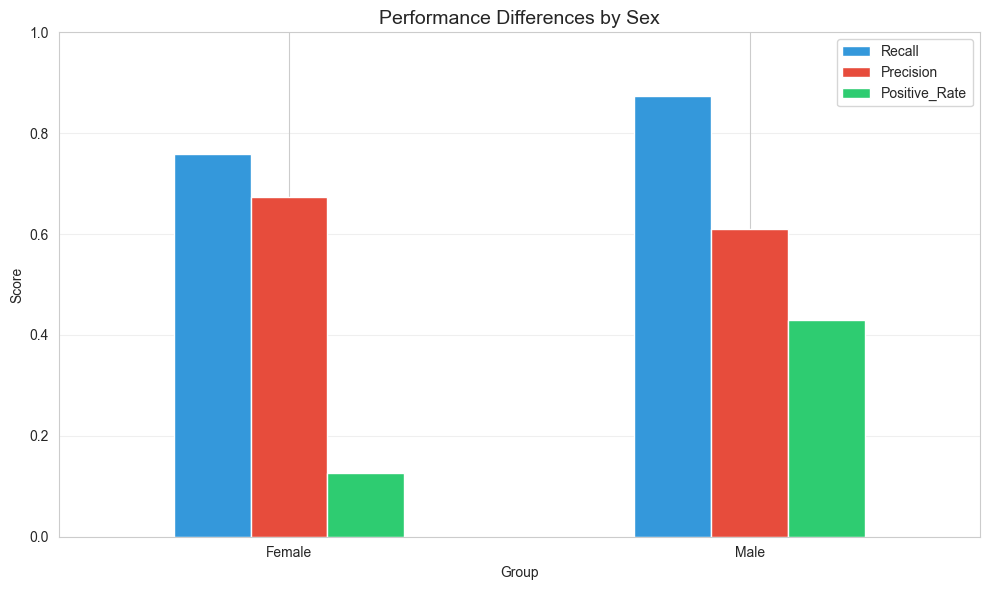

In [6]:

# %%
def get_metrics_by_group(df, group_col):
    groups = df[group_col].unique()
    metrics = []
    
    for g in groups:
        subset = df[df[group_col] == g]
        if len(subset) == 0: continue
        
        acc = accuracy_score(subset['Actual'], subset['Predicted'])
        rec = recall_score(subset['Actual'], subset['Predicted'], zero_division=0)
        prec = precision_score(subset['Actual'], subset['Predicted'], zero_division=0)
        
        # Positive Rate (How often does model predict High Income?)
        pos_rate = subset['Predicted'].mean()
        
        metrics.append({
            'Group': g,
            'Count': len(subset),
            'Accuracy': acc,
            'Recall': rec,
            'Precision': prec,
            'Positive_Rate': pos_rate
        })
        
    return pd.DataFrame(metrics).set_index('Group')

# Run analysis
sex_metrics = get_metrics_by_group(df_audit, 'sex')
print("\n=== FAIRNESS METRICS: SEX ===")
display(sex_metrics)

# Visualization
sex_metrics[['Recall', 'Precision', 'Positive_Rate']].plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Performance Differences by Sex', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/fairness_sex.png', dpi=300)
plt.show()



4. Analyze Fairness by Race


=== FAIRNESS METRICS: RACE ===


,Count,Accuracy,Recall,Precision,Positive_Rate
Group,,,,,
White,6206,0.828070,0.868987,0.614868,0.359813
Black,748,0.911765,0.687500,0.647059,0.136364
Asian-Pac-Islander,236,0.838983,0.809524,0.662338,0.326271
Other,61,0.934426,0.800000,0.571429,0.114754
Amer-Indian-Eskimo,76,0.921053,0.666667,0.666667,0.118421


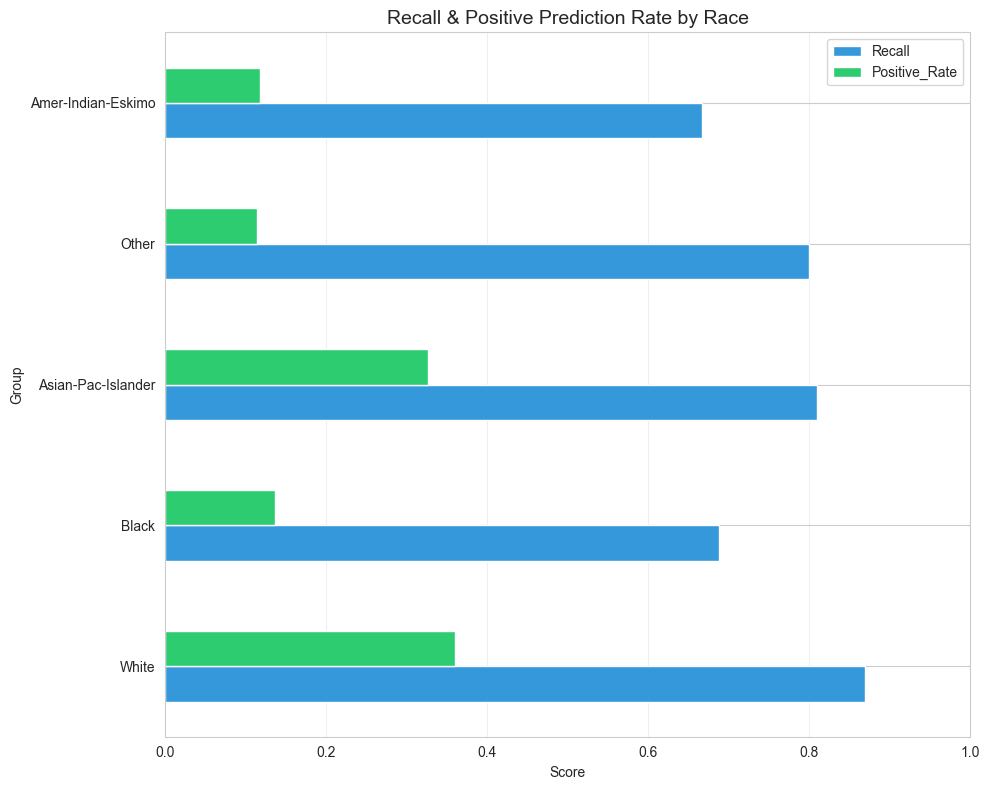

In [7]:

# %%
race_metrics = get_metrics_by_group(df_audit, 'race')
print("\n=== FAIRNESS METRICS: RACE ===")
display(race_metrics)

# Visualization
race_metrics[['Recall', 'Positive_Rate']].plot(kind='barh', figsize=(10, 8), color=['#3498db', '#2ecc71'])
plt.title('Recall & Positive Prediction Rate by Race', fontsize=14)
plt.xlabel('Score')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/fairness_race.png', dpi=300)
plt.show()




 5. Interpretation
    
 **Key Questions for Report:**
 1. **Demographic Parity:** Is the `Positive_Rate` similar across groups? (Likely not; men usually have higher high-income rates in this 1994 dataset).
 2. **Equal Opportunity:** Is `Recall` similar? (i.e., Do we correctly identify high-earning women as often as high-earning men?)
 3. **Bias Check:** If Recall is much lower for a minority group, the model "misses" qualified candidates from that group more often.